# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

In [ ]:
# A Function to Display Tensors Nicely (Feel Free to Skip This)
import torch
import torch.nn as nn
import torch.nn.functional as F

# テンソルを見やすく表示するライブラリをインストール
!pip install git+https://github.com/HayatoHongo/print_formatted_tensor.git
# PyTorchのテンソルを見やすく表示する関数をインポート
from torch_print_tensor import print_formatted_tensor


# **Chapter 18: tiktoken**

### **Section 1: tiktokenを使う**

大きなデータセットで大きなモデル。

過学習することなく、順調に訓練誤差も検証誤差も下がっていきました、

しかし、、、！

---

**遅い！**

---

もっと訓練を高速化する必要があります。

一番先に思いつくのはより良いGPUに課金🤑することです。

しかし私には聞こえます、皆さんの声が、、、

「あんまり課金したくないよー」

そこで、いろいろな高速化のための工夫を加えていくこととなります。

なお、普遍性のないへんてこなテクニックを教えることはありません。

大規模言語モデルの開発企業でも一般的に行われているplaybook的な高速化の手法しか紹介するつもりはないのでご安心を

そもそも Microsoft, Google, Amazon, Meta, Alibaba のLLMの事前学習モデル開発者にとっても当然計算コストは重要な問題なので。

ただ、基本的にはお金をかければ解決できる問題であるということは忘れないでください。

そのため、10,000ドルの学習コストを5,000ドルに削減するために1日中工夫を考えるのはいいと思うのですが、10ドルのコストを5ドルに減らすために1日中考えるみたいな事はやめましょう。

どうすればモデルの計算を高速化できるか？

最も簡単な発想は、**1文字ずつではなく、もっと大きな単位でトークン化する**ことです。

現代のChatGPTなどのLLMはサブワードごとにトークン化しています。

以下のサイトにアクセスしてください。

https://platform.openai.com/tokenizer

`show example`を押してみてください。

ちなみに、これからめちゃくちゃ使うことになる`tiktoken`というtokenizerのライブラリは、GPT-3(Legacy)に対応しています。

英語以外の言語を入力すると「?」が出てきますが、これはUTF-8のバイトにencodeされて、文字として表示できなくなっているだけで、エラーではないので安心してください。

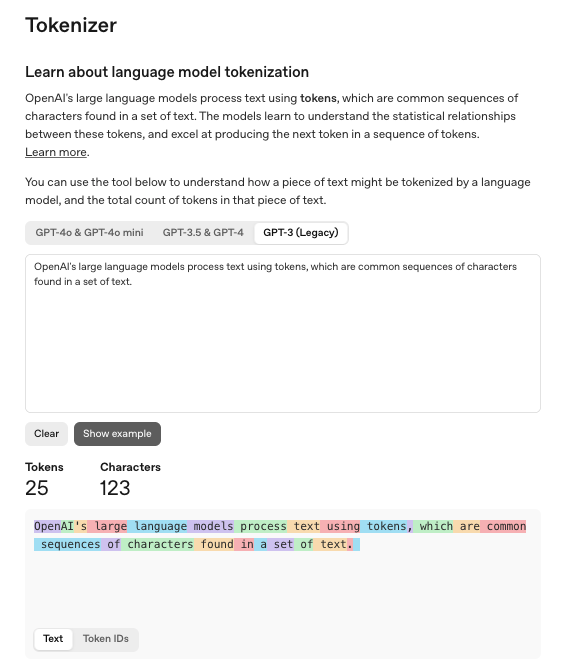

このように、ChatGPT をはじめとする現代の大規模言語モデル（LLM）は、

**サブワード単位**でテキストを分割してトークン化しています。

たとえば OpenAI のモデルでは、

* **Open → 11505**
* **AI → 20185**

というように、文字列が「サブワード」に分かれ、それぞれが数値 ID（トークン）に対応します。

ここでは、**サブワードをどのような仕組みで作っているか（辞書の構築方法）には触れず**、
まずは **“既にあるトークン化辞書をどう使うか”** に集中して学びます。

サブワード辞書の作り方や、BPE（Byte Pair Encoding）といった内部的な仕組みについては、
後の章で詳しく解説していきましょう。

`tiktoken` は、OpenAI が提供する トークナイザー で、GPTモデルがテキストをどのようにトークン（単語のような単位）に分割するかをシミュレートできます。

In [ ]:
import tiktoken

```
関数: tiktoken.get_encoding
引数: "gpt2"
```

- tiktoken.get_encoding("gpt2") は、GPT-2 モデルに対応した トークナイザーを取得します。
- 得られたトークナイザーは、テキストをトークンIDに変換したり、逆にデコードするために使われます。

In [ ]:
encoder = # TODO: 関数(引数)

```python
インスタンス: encoder
メソッド: encode
引数: "tiktoken is great!"
```

* `encode` は、文字列を **トークンIDのリスト** に変換します。
* 結果の `encoded` は整数のリストになります。
* ここでの `encoder` は `get_encoding()` で取得されたエンコーディングオブジェクトを指します。

In [ ]:
encoded = # TODO: インスタンス.メソッド（引数）
print(encoded)

```python
インスタンス: encoder
メソッド: decode
引数: THINK_BY_YOURLSELF
```

* `decode` は、トークンIDのリストを文字列に復元するメソッドです。
* `encoder`という名前なので`encode`しかできないと勘違いされがちですが、`decode`もできます。もともと`encoder`というインスタンス名自体が任意で自分で決めたものでもりますし。ただ、`encoder`や`enc`というインスタンス名をつけるのが一般的です。

In [ ]:
decoded = # TODO: インスタンス.メソッド（引数）
print(decoded)

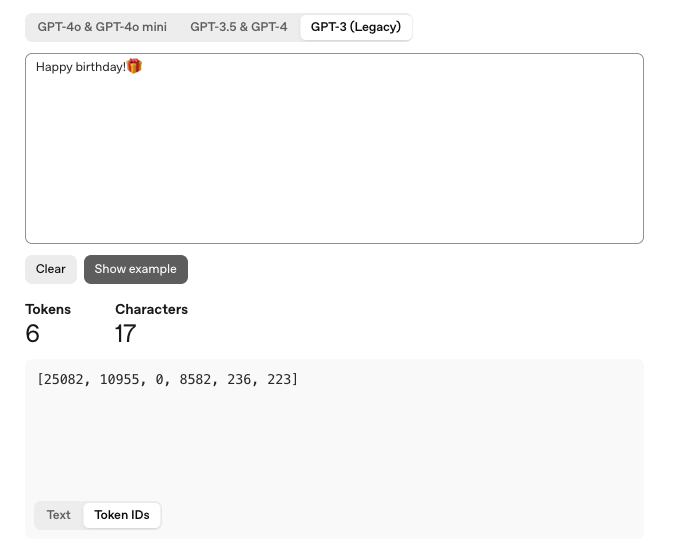

In [ ]:
# Heppy:25082  birthday:10955, !:0, 🎁:8582, 236, 223
prompt = encoder.encode("Happy birthday!🎁")
print(prompt)

## ◆ なぜ英語以外の言語をエンコードすると文字列が長くなるのか？

GPT 系モデルが使う **tiktoken の辞書（サブワード辞書）は英語を中心に最適化**されています。
そのため、

* **英語でよく出てくる単語・部分語（サブワード）**は、辞書に登録されており短いトークンで表現できる
* **英語以外（日本語・中国語など）でよく出る文字や単語は辞書に少ない**

という差が生まれます。

辞書に無い文字は、そのまま「1 文字」として扱えず、
**もっと細かい単位（バイト）に分解してからトークン化**されます。

---

## ◆ 「バイト」とは？（UTF-8 の観点で）

**バイト（byte）**

* コンピュータで扱う一番基本的な情報単位（8 ビット）
* 1 バイト = 0〜255 の数を表現できる
* アルファベットや数字の多くは **1 バイトで表現できる**

**UTF-8**（世界中の文字を扱うための文字コード）では、
文字ごとに次のようにバイト数が異なります：

| 文字                      | UTF-8で必要なバイト数 |
| ----------------------- | ------------- |
| 英語（A, B, C, a, b, c…）   | **1 バイト**     |
| アクセント付き欧州文字（é, ö…）      | **1 バイト**     |
| 日本語・中国語など（漢字・ひらがな・カタカナ） | **2 ~ 3 バイト**     |
| 絵文字（😀など）               | **2 ~ 3 バイト**     |

つまり、英語以外の文字は **1 文字でも複数バイト**になることが多いのです。

---

## ◆ 辞書にない文字は「バイト単位で分割」される

tiktoken の仕組みでは：

* 辞書にあるサブワード → **1 トークンで表現できる**
* 辞書にない文字 → 文字を UTF-8 の **バイト列に分解して、それぞれをトークン化**する

例：

* 英語「hello」 → 辞書にあるので **1 トークン**
* 日本語「日」 → 辞書に無ければ

  * UTF-8 バイト列（2バイト） = **2 トークン**

というように、
**英語以外では1トークンあたりの情報量が小さくなり、トークン数が増える＝文字列が長く見える**
という現象が起きます。


---

## ◆ まとめ（とても簡潔に）

* tiktoken の辞書は英語中心
* 辞書にない文字は UTF-8 の **バイト（最小単位）** に分解される
* 非英語はバイトに分解されることが多い
* そのため英語以外は **トークン数が増え、見かけ上長くなる**

In [ ]:
zh_prompt = encoder.encode("祝你生日快乐!🎁")
print(zh_prompt)

In [ ]:
ja_prompt = encoder.encode("お誕生日おめでとう!🎁")
print(ja_prompt)

In [ ]:
zh_decoded = encoder.decode(zh_prompt)
print(zh_decoded)

In [ ]:
ja_decoded = encoder.decode(ja_prompt)
print(ja_decoded)

In [ ]:
import tiktoken

tokens = [2515, 232, 45739, 243, 37955, 33768, 98, 2515, 232, 1792, 223, 30640, 30201, 29557, 0, 8582, 236, 223]

for i, t in enumerate(tokens):
    s = encoder.decode_single_token_bytes(t).decode("utf-8", errors="replace")
    print(f"{i:02d}: {t:5d} → {repr(s)}")

**Section 1: tiktokenを使う**<label><input type="checkbox"> Mark as Done</label>

### **Section 2: Byte Pair Encodingの事前知識（読むだけ）**

どうすればモデルの計算を高速化できるか？

最も簡単な発想は、**1文字ずつではなく、もっと大きな単位でトークン化する**ことです。

たとえば
`word` を

```
[w], [o], [r], [d]
```

の 4 トークンに分ける代わりに、
1つのトークン `[word]` として扱えば、シーケンス長は 1/4 になります。

これで計算コストが大幅に下がります。

---

## 🔍 しかし、「すべての単語を1トークンにする」は現実的ではありません

ここで問題になるのが **OOV（Out-of-Vocabulary）** です。

* Mirzayeva (人の名前)
* Tokyo
* state-of-the-art
* 新語・専門用語
* 製品名・固有名詞

など、自然言語の語彙には限りがありません。

つまり言語タスクは **open-vocabulary（語彙が無限）** の問題。

すべての単語を事前に登録しておくのは不可能です。

---

さらに、世界には大量に複合語を作ってしまう言語もあります。

例えばドイツ語 🇩🇪 が代表例です。

**Abwasserbehandlungsanlage**

...????? 😎🇩🇪🍺

正解:（sewage water treatment plant：下水処理施設）





ドイツ語は意味のある語をどんどん連結して 1 単語にしてしまいます。

特に機械翻訳の世界では英語🇺🇸 ↔ ドイツ語🇩🇪 が代表的なタスクだったので、

**ドイツ語の大量の複合語は大きな問題でした。**

---

## 🔍 では、文字レベルに戻せば OOV は起きない？

確かに、文字単位にすれば
**どんな単語でも絶対に表現できます。**

しかしその代わり：

* トークン数が非常に長くなる
* 計算コストが巨大
* 文構造や形態素パターンを学習しにくい

といった問題があります。

---

## 🔍 言語学的に意味のある分割（形態素解析）

たとえば「Abwasserbehandlungsanlage」を意味のある形態素に分解すると：

* **Abwasser**（汚水 = Ab〔除去〕 + Wasser〔水〕）
* **Behandlungs-**（処理の = behandeln〔処理する〕＋ -ung）
* **Anlage**（施設）

非常に自然で正しい分割ですが、

* 言語知識が必要
* 言語ごとに個別の形態素解析器が必要

という理由で実務的には難しいのが現実です。

---

# 🎯 **そこで登場したのが BPE（Byte Pair Encoding）**

BPE のアイデアはとてもシンプルです：

### **1. まず文字（または byte）を基本単位として開始する（open vocabulary を保証）**

※2015 の原論文は文字レベル。
※GPT 系は UTF-8 バイトレベル。

### **2. 訓練データ中で頻出する文字列の組み合わせを、頻度の高い順に次々とマージする**

これにより：

* 新語・造語は文字から組み立て可能（open vocabulary）
* よく出現する単語・部分語は圧縮されて短くなる（高い圧縮率）
* 自然に形態素っぽいパターンも学習される（言語学的に厳密ではないが実用的）

**文字レベルの柔軟性と単語レベルの効率の“ちょうど良いバランス”** を実現します。

---

##  🌍 **ドイツ語は BPE の恩恵を最もわかりやすく示した言語だが、**

BPE が広く採用された理由は“普遍的に強い”から

確かに、ドイツ語のような複合語が多い言語は
**BPE のメリットが劇的に見える代表例**でした。

しかし BPE が現代 NLP の標準になった理由は
**ドイツ語だけのためではありません。**

BPE は他にも多くの言語と相性が良かったのです。

### ✔ 日本語・中国語（分かち書きなし）

→ 単語の境界が曖昧でも subword が自然に機能する

### ✔ トルコ語・フィンランド語（語形変化が爆発）

→ 膠着語では形態素が無限に増える
→ word-level が完全に破綻

### ✔ ロシア語・ポーランド語（屈折が激しい）

→ 語形変化が多すぎて辞書登録が不可能

### ✔ 英語（新語・スラング・固有名詞が無限）

→ 語彙が常に膨張するインターネット時代に対応

### ✔ コード（Python, HTML, URL）

→ 自然言語ではない記号列にも強い

このように **BPE は「特定言語用の手法」ではなく、
あらゆる言語と記号体系を一貫して扱える普遍的なアルゴリズム** だったことが大きいのです。

---

# 🧠 **BPE が NLP 史上の標準になった理由（総まとめ）**

* OOV がゼロ
* 圧縮率が高い → Transformer の計算効率と相性抜群
* 言語を問わず適用できる（普遍性）
* 形態素的パターンを自然に学習
* 辞書や解析器などの言語依存処理が不要
* 多言語モデル（BERT, GPT）でそのまま使える
* コードや絵文字などの非言語にも対応

ドイツ語の複合語は「BPE の強みを示す象徴的な例」でしたが、

BPE が勝ち残った理由は **“どの言語にも効く”** 普遍性が圧倒的だったためです。

その普遍性が最初から意図されていたかどうかは分かりませんが、結果的に標準のtokenizer手法となりました。

反対に、それまで盛んだった言語ごとの形態素解析は下火になっていきました。

---

言語ごとの形態素解析が盛んだった2015年にあなたが生きていたとします。

もしあなたが2015年にこの論文を見ていたら、果たしてどう反応すれば良かったのでしょう? https://arxiv.org/pdf/1508.07909

なお、最初の論文では言語的な普遍性が強調されているわけではありません。

むしろ低頻度単語に注目したニッチな研究にすら思えます。

ただ、ドイツ語の複合語の対応だけではなく、ロシア語の名前の翻訳への対応力など、このシンプルな手法の普遍性はしっかり書かれています。

また、結論の最後にも

```plain
While the relative effectiveness will depend on
language-specific factors such as vocabulary size,
we believe that subword segmentations are suit-
able for most language pairs
```

という普遍性への期待が書かれています。
<br><br>

私たちは想像を広げなければなりません。

ある時、ある研究から出てきた、シンプルな手法が、圧倒的な普遍性を誇り、他の研究も含めて分野全体を席巻してしまうことを。

つまり普遍性とは研究の質を決める非常に重要なキーなのです。

領域に特化したエンジニア的な職人芸にキャリアを預けることはリスクがあります。

むしろ、職人芸を駆逐して普遍化していく部分に思考を寄せていくのです。

---

補足

このBPEは2年後にあの伝説の論文`Attention is all you need`(2017)でも採用されることになります。元々の`Attention is all you need`も英独翻訳タスクなので、普遍性に着目したというよりかは、タスクが共通していたからだと思われるので自然な流れですね。


余談

AIがAIについて完璧に教えてくれて教材も勝手に作ってしまったら、もう僕のやってる教材作りとかもいらなくなっちゃうね笑

普遍化の波のなかで職人芸は消失し、職人たちは失業していく、、、

ただ逆にいうと、自分自身を失業させようとすれば普遍化の波を作る側になれるかも

自分のスキルセットをあえて時代遅れにする発明をした人たちが常に前を行く

🔥 outdate yourself!

**Section 2: Byte Pair Encodingの事前知識（読むだけ）**<label><input type="checkbox"> Mark as Done</label>

### **Section 3: tiktokenで学習させる**

In [ ]:
data_file = "https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu/resolve/main/sample/10BT/000_00000.parquet"

In [ ]:
from datasets import load_dataset
ds = load_dataset("parquet", data_files=data_file, split="train", cache_dir="/content/fineweb")

`ds`は HuggingFace Datasets ライブラリ独自の `Dataset` クラスのインスタンスになっています。

In [ ]:
ds

最初の要素を見てみましょう。

In [ ]:
ds[0]

`ds` には、各データサンプルごとに `text` カラムがあり、そこに文章が格納されています。

そのため、文章の区切りとして、前回は「🄴」という特殊文字を使いましたが、

tiktokenには`<|endoftext|>`という特殊トークンがあるので、今回はこれを使います。

`<|endoftext|>` を区切り文字として利用し、複数の文章を無理なく連結します。

```python
インスタンス: THINK_BY_YOURSELF
メソッド: encode
引数: boundary, allowed_special="all"
```

* 引数 `allowed_special="all"` により、すべての **特殊トークン（例: <|endoftext|> など）** をエンコード可能にします。
* 通常、特殊トークンは誤ってエンコードされるのを防ぐため無効化されていますが、このオプションで明示的に許可します。


In [ ]:
# 文書境界
boundary = "<|endoftext|>"
encoded_boundary = # TODO: インスタンス.メソッド（引数）
print(encoded_boundary)

In [ ]:
with open("fineweb.txt", "w", encoding="utf-8") as f:
    for sample in ds:
        f.write(boundary + sample["text"])

In [ ]:
# `fineweb.txt`のディスクサイズを計測するコマンド。通常の関数とは異なります。
!ls -lh fineweb.txt

実は、この `fineweb.txt` は **ディスクサイズで約 3.3GB** もあります。

データのロードは文字のencodingなどの重たい処理を含んでいます。

このまま全データをロードしようとすると、**システム RAM が不足してクラッシュ**してしまいます。

前回は 約 70 万サンプルのうち、5万サンプルだけを使用した`nanofineweb.txt`を作成しました。

今回はtiktokenを用いてサブワードでトークン化しているため、圧縮率が高いです。

データがすぐになくなってしまいます。

そこで、10万サンプルを使用します。

本当はもっとサンプルが必要なのですが、システムRAMの制限からこの量としています。

In [ ]:
with open("nanofineweb.txt", "w", encoding="utf-8") as f:
    for i, sample in enumerate(ds):
        if i >= 100000:
            break
        f.write(boundary + sample["text"])

In [ ]:
# `nanofineweb.txt`のディスクサイズを計測するコマンド。通常の関数とは異なります。
!ls -lh nanofineweb.txt

`nanofineweb.txt`について、最初の10,000文字を表示してみましょう。

In [ ]:
with open("nanofineweb.txt", "r", encoding="utf-8") as f:
  text = f.read(10000)
  print(text)

`Dataloader`クラスをtiktokenライブラリ対応に変えます。

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`tiktoken`　`openai`　`get_encoding`　`encoder`　`decoder`　`encode`　`decode`

In [ ]:
import torch
########## NEW ##########
import ________
########## NEW ##########

class DataLoader:
    def __init__(self, text, config):
        self.config = config  # Configuration Object

        ########## NEW ##########
        self.encoder = ________.___________("gpt2")
        self.vocab_size = self.encoder.n_vocab
        ########## NEW ##########

        # Encode and convert to tensor.
        self.data = torch.tensor(self.encode(text), dtype=torch.long)

        # Split into training/validation data.
        self.train_data, self.val_data = self.split_data()

    def encode(self, text):
        ########## NEW ##########
        # tiktokenでエンコード
        return self._______._____(text, allowed_special="all")
        ########## NEW ##########

    def decode(self, indices):
        ########## NEW ##########
        # tiktokenでデコード
        return self._______.______(indices)
        ########## NEW ##########

    def split_data(self):
        split_index = int(0.9 * len(self.data))  # 90% train, 10% val
        return self.data[:split_index], self.data[split_index:]

    def get_batch(self, split):
        data = self.train_data if split == 'train' else self.val_data
        start_indices = torch.randint(
            len(data) - self.config.input_sequence_length,
            (self.config.batch_size,)
        )

        input_sequences = torch.stack([
            data[start:start + self.config.input_sequence_length]
            for start in start_indices
        ])
        target_sequences = torch.stack([
            data[start + 1:start + self.config.input_sequence_length + 1]
            for start in start_indices
        ])

        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )

<details>
<summary>クリックして答えを表示/非表示</summary>

```python
import torch
########## NEW ##########
import tiktoken
########## NEW ##########

class DataLoader:
    def __init__(self, text, config):
        self.config = config  # Configuration Object

        ########## NEW ##########
        self.encoder = tiktoken.get_encoding("gpt2")
        self.vocab_size = self.encoder.n_vocab
        ########## NEW ##########

        # Encode and convert to tensor.
        self.data = torch.tensor(self.encode(text), dtype=torch.long)

        # Split into training/validation data.
        self.train_data, self.val_data = self.split_data()

    def encode(self, text):
        ########## NEW ##########
        # tiktokenでエンコード
        return self.encoder.encode(text, allowed_special="all")
        ########## NEW ##########

    def decode(self, indices):
        ########## NEW ##########
        # tiktokenでデコード
        return self.encoder.decode(indices)
        ########## NEW ##########

    def split_data(self):
        split_index = int(0.9 * len(self.data))  # 90% train, 10% val
        return self.data[:split_index], self.data[split_index:]

    def get_batch(self, split):
        data = self.train_data if split == 'train' else self.val_data
        start_indices = torch.randint(
            len(data) - self.config.input_sequence_length,
            (self.config.batch_size,)
        )

        input_sequences = torch.stack([
            data[start:start + self.config.input_sequence_length]
            for start in start_indices
        ])
        target_sequences = torch.stack([
            data[start + 1:start + self.config.input_sequence_length + 1]
            for start in start_indices
        ])

        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )
```

それ以外は前回のChapterと同じです。

In [ ]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)

class PositionEmbedding(nn.Module):
    def __init__(self, input_sequence_length = 8, embedding_dim = 8):
        super().__init__()
        # 位置埋め込み層
        self.position_embedding_layer = nn.Embedding(input_sequence_length, embedding_dim)

    def forward(self, input_indices):
        # 入力テンソル input_indices の形状：[バッチサイズ、シーケンス長]。
        sequence_length = input_indices.shape[1]

        # シーケンス長に応じた位置インデックスを作成する（例：[0, 1, 2, ..., sequence_length-1]）
        position_indices = torch.arange(sequence_length, device=input_indices.device)

        # 位置インデックスの埋め込みベクトルを取得する
        position_embeddings = self.position_embedding_layer.forward(position_indices)

        return position_embeddings

class EmbeddingModule(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # 各トークンの埋め込み層
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)  # 単語埋め込み層
        self.position_embedding_layer = PositionEmbedding(input_sequence_length = config.input_sequence_length, embedding_dim = config.embedding_dim)  # 位置情報を埋め込む

    def forward(self, input_indices):
        # トークン埋め込みを取得
        token_embeddings = self.token_embedding_layer.embed(input_indices)

        # 位置埋め込みを取得する
        position_embeddings = self.position_embedding_layer.forward(input_indices)

        # トークン埋め込みと位置埋め込みを追加する
        embeddings = position_embeddings + token_embeddings
        return embeddings


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        # ドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)
        self.head_size = head_size

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)
        attention_weights = self.dropout(attention_weights)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)

        # 出力のドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        # 最終出力にドロップアウトを適用する
        output = self.dropout.forward(projected)

        return output

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
            nn.Dropout(config.dropout_rate),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits

class nanoGPT(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.embedding = EmbeddingModule(vocab_size, config=config)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        self.criterion = nn.CrossEntropyLoss()

    # テキストを生成する
    def generate(self, input_indices, max_new_tokens):
        # 指定したトークン数max_new_tokensのみ生成する
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # 入力を切り取る

            # 順伝播は `(likelihood, loss)` を返す—`likelihood` のみを `logits` として保持する。
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # 最後のトークンのロジットを抽出する
            probs = F.softmax(last_logits, dim=-1) # Softmaxで尤度を確率に変換する

            # 次のトークンをサンプリングする
            next_token = torch.multinomial(probs, num_samples=1)

            # 新しいトークンを統合し、input_indicesを更新する。
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # 最終的な`input_indices`を返す。長さは元の`input_indices`＋`max_new_tokens`
        return input_indices

    # 尤度と損失を計算する
    def forward(self, input_indices, target_indices):
        embeddings = self.embedding(input_indices)
        blocks_output = self.blocks(embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

`Trainer`クラスを定義します。Chapter16と完全に同じです。

In [ ]:
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        self.train_losses = []
        self.val_losses = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}

    def train(self):
        # (configで指定された回数+1)だけtrain_stepを実行する。
        for step in range(self.config.total_training_steps+1):
            # 100回ごとに評価する。
            if step % self.config.evaluation_frequency == 0:
                if step == 0:
                  tokens_per_second = None
                  total_train_time = 0
                else:
                  current_eval_start_time = time.time()
                  evaluation_interval = current_eval_start_time - last_eval_end_time
                  total_train_time += evaluation_interval
                  tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
                  tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

                eval_loss = self.evaluate()
                total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step

                print(
                    f"step {step:05d} | "
                    f"train loss {eval_loss['train']:.4f} | "
                    f"val loss {eval_loss['val']:.4f} | "
                    f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | "
                    f"tokens {total_seen_tokens:,} | "
                    f"time {total_train_time:.2f}s"
                )

                self.steps.append(step)
                self.train_losses.append(eval_loss['train'])
                self.val_losses.append(eval_loss['val'])
                self.total_seen_tokens_list.append(total_seen_tokens)
                self.total_train_time_list.append(total_train_time)

                # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
                last_eval_end_time = time.time()

            # 1回の学習ステップ（毎回行う主な処理）
            train_loss = self.train_step()

In [ ]:
# モデル設定を保存する設定クラス
class ModelConfig:
    batch_size = 16
    input_sequence_length = 512  # データロードにかかる時間の割合を下げるため、長めのシークエンスを一度に取り出す。
    ########## NEW ##########
    total_training_steps = 5_000  # おおよそ1時間くらいかかる
    ########## NEW ##########
    device_type = 'cuda'  # 使用デバイスはGPUに固定する
    evaluation_frequency = 100  # モデル性能評価の頻度
    learning_rate = 0.001  # 学習率
    evaluation_loops = 10  # 評価中の繰り返し回数
    embedding_dim = 512  # 埋め込み層サイズ（特徴ベクトルの次元数）
    hidden_dim = 2048
    num_attention_heads = 8  # アテンションヘッドの数
    layer_count = 4  # モデルの層数
    dropout_rate = 0.1  # ドロップアウト確率
    random_seed_value = 1337  # 再現性のための乱数シード

In [ ]:
# 設定を読み込みシードを設定する
config = ModelConfig()
torch.manual_seed(config.random_seed_value)  # 再現性確保のため乱数シードを設定

In [ ]:
# データを読み込む。ファイルが大きいほどシステムRAMを消費します。
with open("/content/nanofineweb.txt", 'r', encoding = 'utf-8') as f:
    text_data = f.read()
data_loader = DataLoader(text_data, config)

tiktokenの語彙は巨大で、約50,000です。

In [ ]:
vocab_size = data_loader.vocab_size
print(f"Vocab size: {vocab_size}")

In [ ]:
# モデルとオプティマイザを初期化する
model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

モデルのパラメータ数は前回の17Mから64Mと急激に増加します。

依然として計算コストにおける`nn.Embedding`の影響は軽微ですが、

出力層は大きな負担となります。

In [ ]:
# モデルのパラメータ数を表示する
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

### 🚀 学習スタート！

今回は **15 GB RAM の T4 GPU** を使用し、
`batch size = 16`、`total steps = 5,000` の設定で進めます。

モデルサイズが大きくなった影響で、1stepあたりに時間がかかるようになったため、

total steps は前回の10,000から5,000に引き下げられています。

本当は10,000step学習させたいのですが、とりあえず前回の5,000stepまでの比較はできるのでよしとしましょう。

**学習完了までにおよそ1時間**ほどかかります😇

同じく、かなりヒマです…。

余裕がある方は論文を読んでみましょう。

 https://arxiv.org/pdf/1508.07909


In [ ]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer = Trainer(model, optimizer, data_loader, config)
trainer.train()

横軸を`Step`、縦軸を`Loss`として`matplotlib`を使って描画しましょう。

In [ ]:
# グラフ描画。
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(trainer.steps, trainer.train_losses, label='Train Loss')
plt.plot(trainer.steps, trainer.val_losses, label='Validation Loss')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True)
plt.show()

おそらく、文字ごとにやった時よりもロスの下がり方が鈍くなっているはずです。

ぜひ、結果を自分なりに考察してください。

In [ ]:
# 推論もやってみる
# 評価モードに切り替え。ドロップアウトを無効化する。
model.eval()
print("Model set to eval mode")

In [ ]:
prompt = "New York is"
print(f"\n入力プロンプト: {prompt}")

# トークナイズしてテンソル化
encoded = data_loader.encode(prompt) # テキストをIDにエンコード
print("encoded", encoded)
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # IDのリストをテンソルの形式に変換する
print_formatted_tensor(encoded_tensor)
encoded_tensor = encoded_tensor.unsqueeze(0)  # バッチ次元追加
print_formatted_tensor(encoded_tensor)
encoded_tensor = encoded_tensor.to(config.device_type) # cuda(GPU)にencoded_tensorを転送する
print_formatted_tensor(encoded_tensor)

In [ ]:
# テキスト生成
generated_text = model.generate(encoded_tensor, max_new_tokens=512)

In [ ]:
decoded_text = data_loader.decode(generated_text[0].tolist())
print(decoded_text)

今回もT4 GPUをたっぷり使って学習してるので、学習ログはきちんと保管しましょう。

おすすめはGoole Driveです。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 学習済み trainer からログをまとめる
results = {
    "step": trainer.steps,
    "train_loss": trainer.train_losses,
    "val_loss": trainer.val_losses,
    "total_seen_tokens": trainer.total_seen_tokens_list,
    "total_train_time": trainer.total_train_time_list,
}

print(results)

In [ ]:
import pandas as pd
# pandas の DataFrame に変換
df = pd.DataFrame(results)

In [ ]:
df

In [ ]:
# 保存先のフォルダを作成する
import os
dir_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter18"
os.makedirs(dir_path, exist_ok=True)

In [ ]:
# csvファイルとして保存する先のパスを指定する。
save_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter18/training_logs.csv"

In [ ]:
# CSVとして保存
df.to_csv(save_path, index=False)
print(f"✅ CSV saved to: {save_path}")

In [ ]:
# クラス属性を辞書化
config_class_dict = vars(config.__class__)
print(config_class_dict)

In [ ]:
# 辞書の (key, value) ペアを取得
config_dict_items = config_class_dict.items()
print(config_dict_items)

In [ ]:
config_dict = {
    key: value
    for key, value in config_dict_items
    if not key.startswith("__")
}

print(config_dict)

In [ ]:
# 保存先のファイルパスを作成する。
# dir_path = "/content/drive/MyDrive/nanoGPT_logs/Chapter17"
config_path = os.path.join(dir_path, "model_config.json")
print(config_path)

In [ ]:
import json
# ファイルを「書き込みモード(w)」で開き、変数`f`で操作できるようにする
with open(config_path, "w") as f:
    json.dump(config_dict, f)

print(f"✅ Config saved to: {config_path}")

**Section 3: tiktokenで学習** <label><input type="checkbox"> Mark as Done</label>

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**Chapter 18: tiktoken** <label><input type="checkbox"> Mark as Done</label>